In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np
import scienceplots
from scipy.stats import linregress
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
%matplotlib inline
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,

   })

## MAKE SURE TO CHANGE THE PATHS BELOW TO THE LOCATION OF YOUR EXCEL FILES

EXCEL_PATH_TV = r"C:\Users\mouly\Dropbox\Codes and Dataset\Field_Vertical.xlsx"
EXCEL_PATH_TH = r"C:\Users\mouly\Dropbox\Codes and Dataset\Field_Horizontal.xlsx"




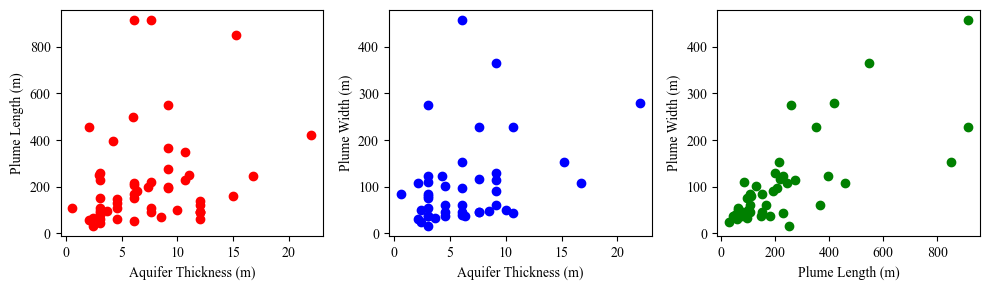

In [2]:
# ----------------------------------------------------------------------
# Load data
# ----------------------------------------------------------------------
data = pd.read_excel(EXCEL_PATH_TV, sheet_name="Data")

At1 = pd.to_numeric(data["Aquifer thickness"], errors="coerce")
Pl1 = pd.to_numeric(data["Plume length"], errors="coerce")
Pw1 = pd.to_numeric(data["Plume width"], errors="coerce")

# ----------------------------------------------------------------------
# Create 1x3 grid
# ----------------------------------------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(10, 3))

# Pair 1: Aquifer Thickness vs Plume Length
sub1 = pd.concat([At1, Pl1], axis=1).dropna()
axs[0].scatter(sub1["Aquifer thickness"], sub1["Plume length"], color='red')
axs[0].set_xlabel('Aquifer Thickness (m)')
axs[0].set_ylabel('Plume Length (m)')

# Pair 2: Aquifer Thickness vs Plume Width
sub2 = pd.concat([At1, Pw1], axis=1).dropna()
axs[1].scatter(sub2["Aquifer thickness"], sub2["Plume width"], color='blue')
axs[1].set_xlabel('Aquifer Thickness (m)')
axs[1].set_ylabel('Plume Width (m)')

# Pair 3: Plume Length vs Plume Width
sub3 = pd.concat([Pl1, Pw1], axis=1).dropna()
axs[2].scatter(sub3["Plume length"], sub3["Plume width"], color='green')
axs[2].set_xlabel('Plume Length (m)')
axs[2].set_ylabel('Plume Width (m)')

plt.tight_layout()
plt.savefig("S1.pdf", dpi=300)
plt.show()

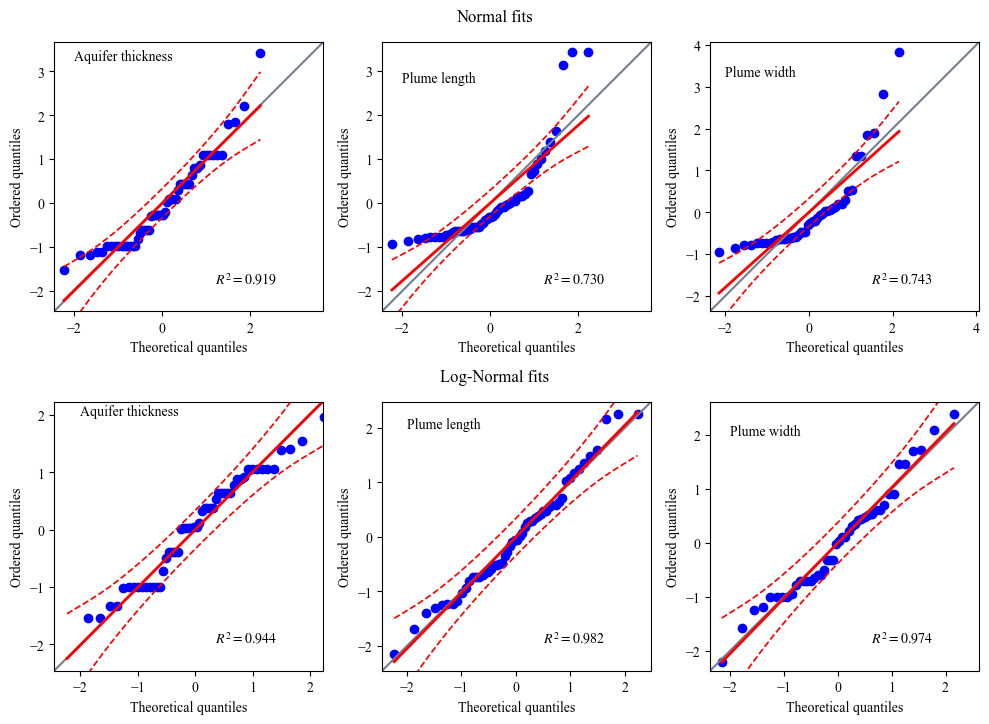

In [3]:
import pingouin as pg

# ----------------------------------------------------------------------
# Load and clean data
# ----------------------------------------------------------------------
data = pd.read_excel(EXCEL_PATH_TV, sheet_name="Data")

At1 = pd.to_numeric(data["Aquifer thickness"], errors="coerce").dropna()
Pl1 = pd.to_numeric(data["Plume length"], errors="coerce").dropna()
Pw1 = pd.to_numeric(data["Plume width"], errors="coerce").dropna()

# Log-normal versions (drop non-positive values first, since log needs > 0)
At1L = np.log(At1[At1 > 0])
Pl1L = np.log(Pl1[Pl1 > 0])
Pw1L = np.log(Pw1[Pw1 > 0])

# ----------------------------------------------------------------------
# QQ plots
# ----------------------------------------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(10, 8))
fig.text(0.5, 0.92, 'Normal fits', ha='center', va='top', fontsize=12)

pg.qqplot(At1, dist='norm', ax=axs[0, 0])
axs[0, 0].text(-2, 3.25, 'Aquifer thickness')
pg.qqplot(Pl1, dist='norm', ax=axs[0, 1])
axs[0, 1].text(-2, 2.75, 'Plume length')
pg.qqplot(Pw1, dist='norm', ax=axs[0, 2])
axs[0, 2].text(-2, 3.25, 'Plume width')

# Title for second row
fig.text(0.5, 0.47, 'Log-Normal fits', ha='center', va='top', fontsize=12)

pg.qqplot(At1L, dist='norm', ax=axs[1, 0])
axs[1, 0].text(-2, 2, 'Aquifer thickness')
pg.qqplot(Pl1L, dist='norm', ax=axs[1, 1])
axs[1, 1].text(-2, 2, 'Plume length')
pg.qqplot(Pw1L, dist='norm', ax=axs[1, 2])
axs[1, 2].text(-2, 2, 'Plume width')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("S2.pdf", dpi=300)
plt.show()

phi=0.1: All=19, O2=35
phi=0.2: All=21, O2=40
phi=0.4: All=32, O2=44
phi=0.5: All=36, O2=43
phi=0.6: All=38, O2=45
phi=0.8: All=44, O2=45
phi=1.0: All=45, O2=47


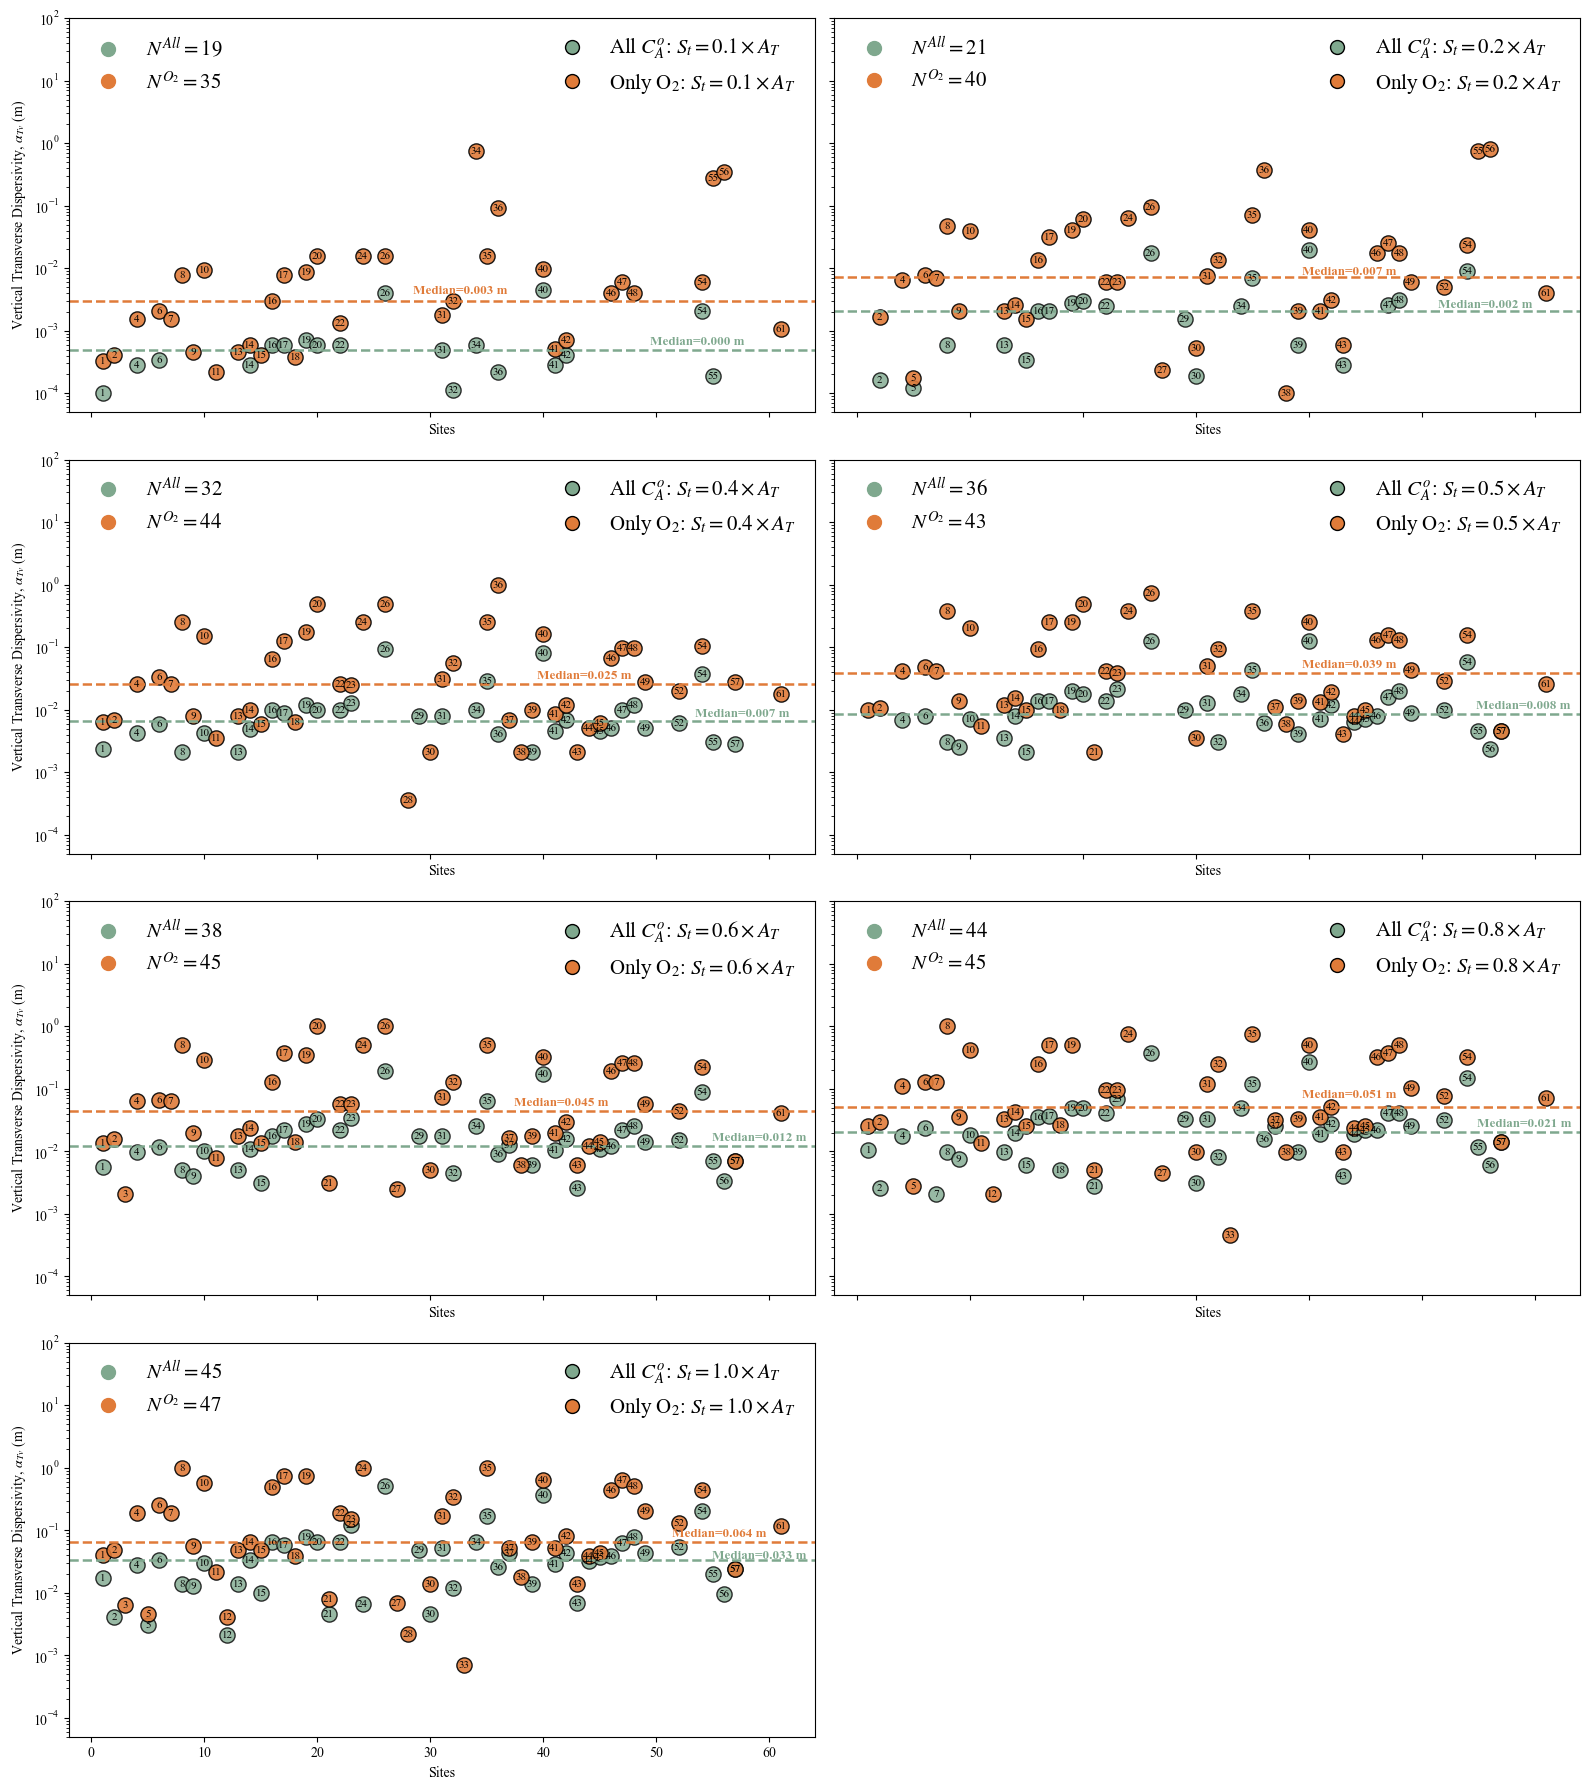

In [4]:
#VERTICAL

# ---------------------------------------------------------------------------
# Load Data
# ---------------------------------------------------------------------------
PHI_VALUES = ["0.1", "0.2", "0.4", "0.5", "0.6", "0.8", "1.0"]

N_ROWS, N_COLS = 4, 2

# ---------------------------------------------------------------------------
# Median label positions
# ---------------------------------------------------------------------------
LABEL_OFFSETS = {
    "0.1": (-2,1.2,-23,1.3),
    "0.2": (0,1.1,-12,1.1),
    "0.4": (2,1.2,-12,1.2),
    "0.5": (3.4,1.2,-12,1.2),
    "0.6": (3.5,1.2,-14,1.2),
    "0.8": (3.5,1.2,-12,1.4),
    "1.0": (3.5,1.05,0,1.2),
}

# ---------------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(
    N_ROWS,
    N_COLS,
    figsize=(16,18),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, phi in enumerate(PHI_VALUES):

    ax = axes[i]

    # -----------------------------------------------------------------------
    # Read sheets
    # -----------------------------------------------------------------------
    df_all = pd.read_excel(
        EXCEL_PATH_TV,
        sheet_name=f"{phi}_All"
    )

    df_o2 = pd.read_excel(
        EXCEL_PATH_TV,
        sheet_name=f"{phi}_O2"
    )

    # -----------------------------------------------------------------------
    # Clean data
    # -----------------------------------------------------------------------
    for df in [df_all, df_o2]:

        df["Site_ID"] = pd.to_numeric(
            df["Site_ID"],
            errors="coerce"
        )

        df["alpha"] = pd.to_numeric(
            df["atv"],
            errors="coerce"
        )

        df.dropna(
            subset=["Site_ID","alpha"],
            inplace=True
        )

        df["Site_ID"] = df["Site_ID"].astype(int)

    # -----------------------------------------------------------------------
    # Site counts (all sites)
    # -----------------------------------------------------------------------
    n_all_sites = df_all["Site_ID"].nunique()
    n_o2_sites = df_o2["Site_ID"].nunique()

    print(
        f"phi={phi}: "
        f"All={n_all_sites}, "
        f"O2={n_o2_sites}"
    )

    # -----------------------------------------------------------------------
    # Median values
    # -----------------------------------------------------------------------
    median_all = df_all["alpha"].median()
    median_o2 = df_o2["alpha"].median()

    # -----------------------------------------------------------------------
    # Scatter plots
    # -----------------------------------------------------------------------
    ax.scatter(
        df_all["Site_ID"],
        df_all["alpha"],
        color="#7FA88E",
        edgecolors="black",
        marker="o",
        s=120,
        alpha=0.8
    )

    ax.scatter(
        df_o2["Site_ID"],
        df_o2["alpha"],
        color="#E07B39",
        edgecolors="black",
        marker="o",
        s=120,
        alpha=0.9
    )

    # -----------------------------------------------------------------------
    # Site labels
    # -----------------------------------------------------------------------
    for _, row in df_all.iterrows():

        ax.text(
            row["Site_ID"],
            row["alpha"],
            str(int(row["Site_ID"])),
            ha="center",
            va="center",
            fontsize=8
        )

    for _, row in df_o2.iterrows():

        ax.text(
            row["Site_ID"],
            row["alpha"],
            str(int(row["Site_ID"])),
            ha="center",
            va="center",
            fontsize=8
        )

    # -----------------------------------------------------------------------
    # Median lines
    # -----------------------------------------------------------------------
    ax.axhline(
        median_all,
        color="#7FA88E",
        linestyle="--",
        linewidth=1.8
    )

    ax.axhline(
        median_o2,
        color="#E07B39",
        linestyle="--",
        linewidth=1.8
    )

    xmax = max(
        df_all["Site_ID"].max(),
        df_o2["Site_ID"].max()
    )

    dx_all,dy_all,dx_o2,dy_o2 = LABEL_OFFSETS.get(
        phi,
        (0,1.3,0,1.3)
    )

    ax.text(
        xmax*0.98 + dx_all,
        median_all*dy_all,
        f"Median={median_all:.3f} m",
        color="#7FA88E",
        fontsize=9.5,
        fontweight="bold",
        ha="right"
    )

    ax.text(
        xmax*0.98 + dx_o2,
        median_o2*dy_o2,
        f"Median={median_o2:.3f} m",
        color="#E07B39",
        fontsize=9.5,
        fontweight="bold",
        ha="right"
    )

    # -----------------------------------------------------------------------
    # Formatting
    # -----------------------------------------------------------------------
    ax.set_yscale("log")
    ax.set_ylim(5e-5,100)

    col = i % N_COLS

    if col == 0:
        ax.set_ylabel(
            r"Vertical Transverse Dispersivity, $\alpha_{Tv}$ (m)"
        )
    else:
        ax.tick_params(labelleft=False)

    ax.set_xlabel("Sites")

    # -----------------------------------------------------------------------
    # Right legend
    # -----------------------------------------------------------------------
    handles_right = [

        mlines.Line2D(
            [],
            [],
            color="#7FA88E",
            marker="o",
            markeredgecolor="black",
            markersize=10,
            linestyle="None",
            label=rf"All $C_A^o$: $S_t={phi}\times A_T$"
        ),

        mlines.Line2D(
            [],
            [],
            color="#E07B39",
            marker="o",
            markeredgecolor="black",
            markersize=10,
            linestyle="None",
            label=rf"Only O$_2$: $S_t={phi}\times A_T$"
        )
    ]

    leg_right = ax.legend(
        handles=handles_right,
        loc="upper right",
        frameon=False,
        fontsize=15
    )

    # -----------------------------------------------------------------------
    # Left legend (counts)
    # -----------------------------------------------------------------------
    handles_left = [

        mlines.Line2D(
            [],
            [],
            color="#7FA88E",
            marker="o",
            linestyle="None",
            markersize=10,
            label=rf"$N^{{All}}={n_all_sites}$"
        ),

        mlines.Line2D(
            [],
            [],
            color="#E07B39",
            marker="o",
            linestyle="None",
            markersize=10,
            label=rf"$N^{{O_2}}={n_o2_sites}$"
        )
    ]

    leg_left = ax.legend(
        handles=handles_left,
        loc="upper left",
        frameon=False,
        fontsize=15
    )

    ax.add_artist(leg_right)

# Hide any unused subplot axes (when len(PHIS) < N_ROWS * N_COLS)
# ---------------------------------------------------------------------------
for j in range(len(PHI_VALUES), N_ROWS * N_COLS):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("S3.pdf", dpi=300)
plt.show()

phi=0.1: AllN=N/A, O2N=5
phi=0.25: AllN=N/A, O2N=20
phi=0.5: AllN=2, O2N=16
phi=0.75: AllN=4, O2N=26


C:\Users\mouly\AppData\Local\Temp\ipykernel_17232\1401374074.py:155: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg_right = ax.legend(
C:\Users\mouly\AppData\Local\Temp\ipykernel_17232\1401374074.py:155: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg_right = ax.legend(
C:\Users\mouly\AppData\Local\Temp\ipykernel_17232\1401374074.py:155: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg_right = ax.legend(
C:\Users\mouly\AppData\Local\Temp\ipykernel_17232\1401374074.py:155: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend

phi=1.0: AllN=7, O2N=31


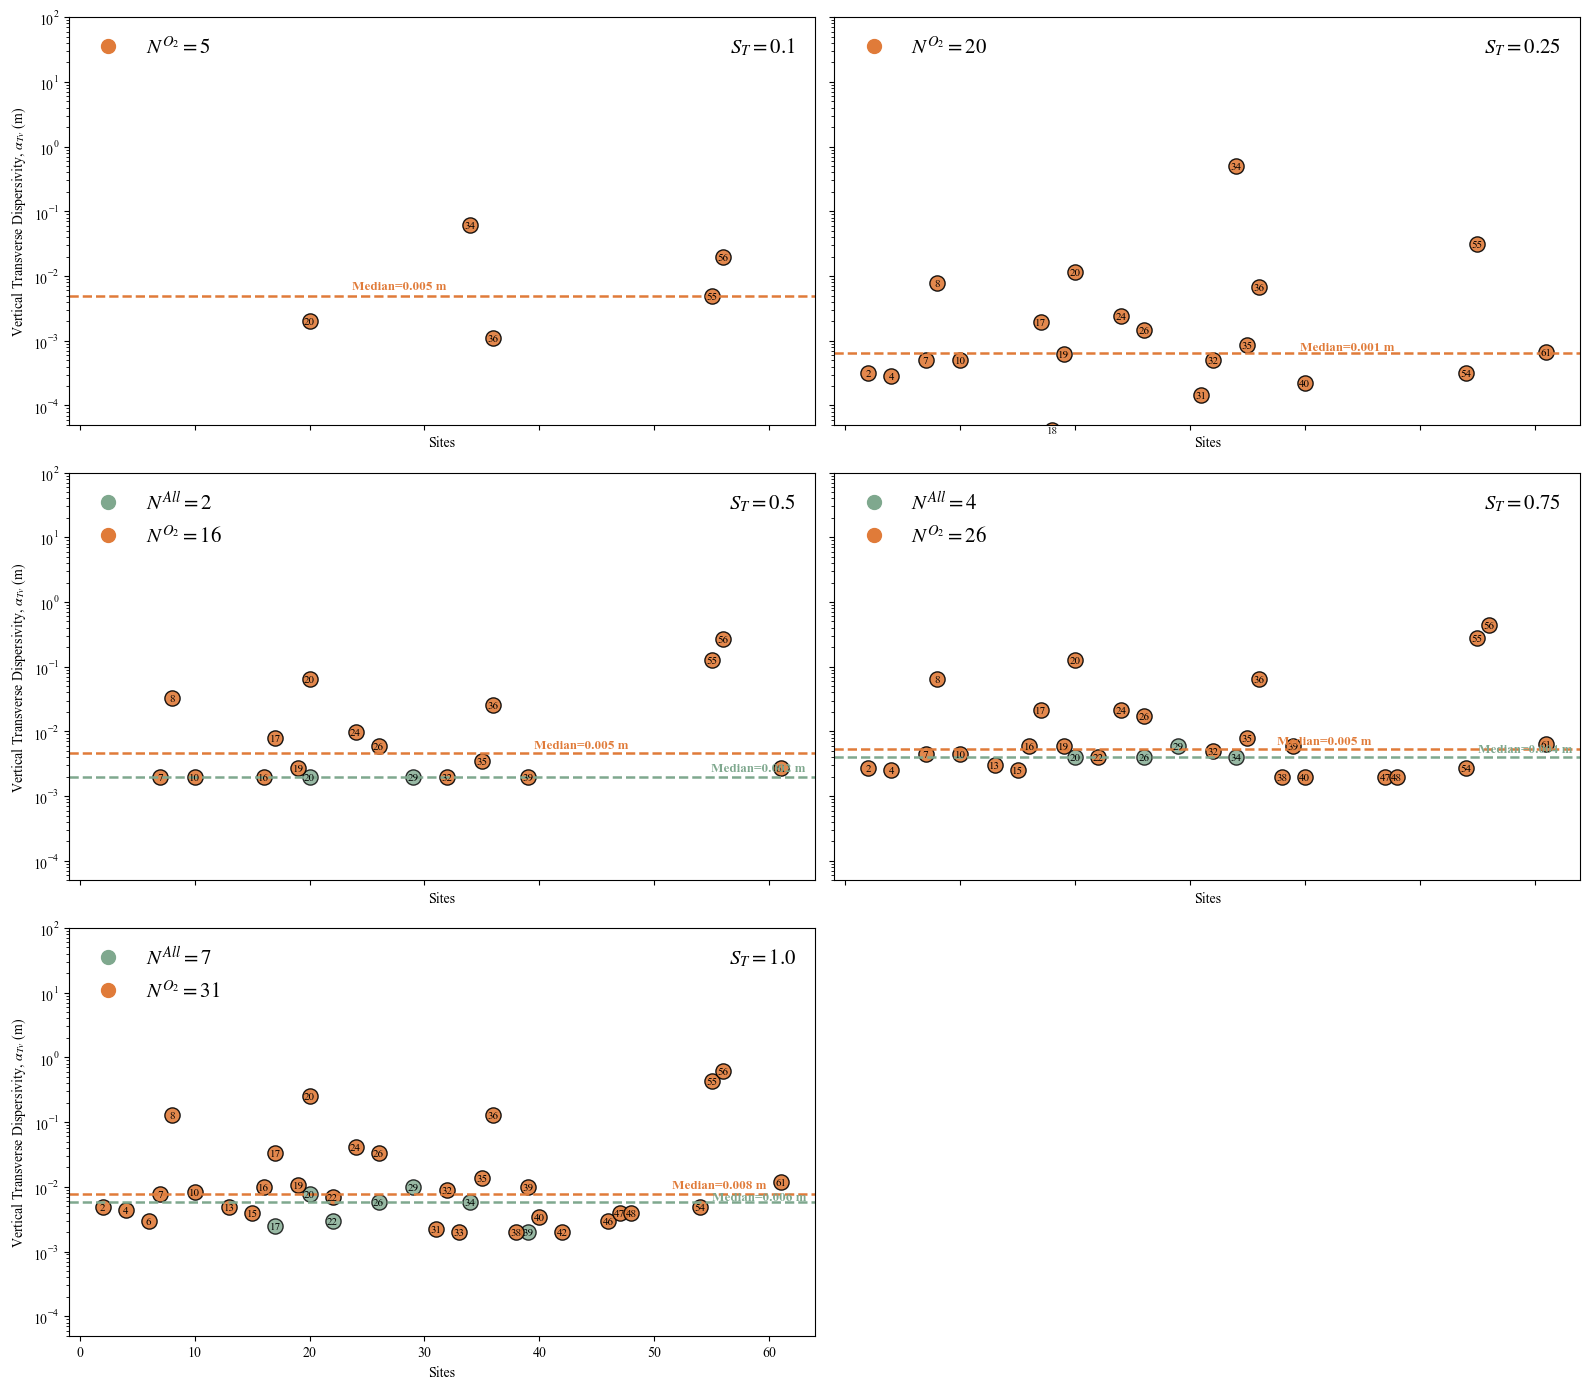

In [5]:
# VERTICAL — O2N + AllN

# ---------------------------------------------------------------------------
# Load Data
# ---------------------------------------------------------------------------
PHI_VALUES_N = ["0.1", "0.25", "0.5", "0.75", "1.0"]   # O2N 
PHIS_ALLN    = ["0.5", "0.75", "1.0"]                   # AllN 

N_ROWS, N_COLS = 3, 2

# ---------------------------------------------------------------------------
# Median label positions (tune per phi as needed, like before)
# ---------------------------------------------------------------------------
LABEL_OFFSETS = {
    "0.1":  (-2, 1.2, -23, 1.3),
    "0.25": (0, 1.1, -12, 1.1),
    "0.5":  (3.4, 1.2, -12, 1.2),
    "0.75": (3.5, 1.2, -14, 1.2),
    "1.0":  (3.5, 1.05, 0, 1.2),
}

# ---------------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(
    N_ROWS,
    N_COLS,
    figsize=(16, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, phi in enumerate(PHI_VALUES_N):

    ax = axes[i]

    # -----------------------------------------------------------------------
    # Read O2N (always present)
    # -----------------------------------------------------------------------
    df_o2n = pd.read_excel(
        EXCEL_PATH_TV,
        sheet_name=f"{phi}_O2N"
    )

    df_o2n["Site_ID"] = pd.to_numeric(df_o2n["Site_ID"], errors="coerce")
    df_o2n["alpha"]   = pd.to_numeric(df_o2n["atv"], errors="coerce")
    df_o2n.dropna(subset=["Site_ID", "alpha"], inplace=True)
    df_o2n["Site_ID"] = df_o2n["Site_ID"].astype(int)

    n_o2n_sites = df_o2n["Site_ID"].nunique()
    median_o2n  = df_o2n["alpha"].median()

    # -----------------------------------------------------------------------
    # Read AllN (only if this phi has a sheet)
    # -----------------------------------------------------------------------
    has_alln = phi in PHIS_ALLN

    if has_alln:
        df_alln = pd.read_excel(
            EXCEL_PATH_TV,
            sheet_name=f"{phi}_AllN"
        )

        df_alln["Site_ID"] = pd.to_numeric(df_alln["Site_ID"], errors="coerce")
        df_alln["alpha"]   = pd.to_numeric(df_alln["atv"], errors="coerce")
        df_alln.dropna(subset=["Site_ID", "alpha"], inplace=True)
        df_alln["Site_ID"] = df_alln["Site_ID"].astype(int)

        n_alln_sites = df_alln["Site_ID"].nunique()
        median_alln  = df_alln["alpha"].median()

        print(f"phi={phi}: AllN={n_alln_sites}, O2N={n_o2n_sites}")
    else:
        print(f"phi={phi}: AllN=N/A, O2N={n_o2n_sites}")

    # -----------------------------------------------------------------------
    # Scatter plots
    # -----------------------------------------------------------------------
    if has_alln:
        ax.scatter(
            df_alln["Site_ID"], df_alln["alpha"],
            color="#7FA88E", edgecolors="black",
            marker="o", s=120, alpha=0.8
        )

    ax.scatter(
        df_o2n["Site_ID"], df_o2n["alpha"],
        color="#E07B39", edgecolors="black",
        marker="o", s=120, alpha=0.9
    )

    # -----------------------------------------------------------------------
    # Site labels
    # -----------------------------------------------------------------------
    if has_alln:
        for _, row in df_alln.iterrows():
            ax.text(
                row["Site_ID"], row["alpha"], str(int(row["Site_ID"])),
                ha="center", va="center", fontsize=8
            )

    for _, row in df_o2n.iterrows():
        ax.text(
            row["Site_ID"], row["alpha"], str(int(row["Site_ID"])),
            ha="center", va="center", fontsize=8
        )

    # -----------------------------------------------------------------------
    # Median lines + labels
    # -----------------------------------------------------------------------
    if has_alln:
        ax.axhline(median_alln, color="#7FA88E", linestyle="--", linewidth=1.8)

    ax.axhline(median_o2n, color="#E07B39", linestyle="--", linewidth=1.8)

    xmax = df_o2n["Site_ID"].max() if not has_alln else max(
        df_alln["Site_ID"].max(), df_o2n["Site_ID"].max()
    )

    dx_all, dy_all, dx_o2, dy_o2 = LABEL_OFFSETS.get(phi, (0, 1.3, 0, 1.3))

    if has_alln:
        ax.text(
            xmax * 0.98 + dx_all, median_alln * dy_all,
            f"Median={median_alln:.3f} m",
            color="#7FA88E", fontsize=9.5, fontweight="bold", ha="right"
        )

    ax.text(
        xmax * 0.98 + dx_o2, median_o2n * dy_o2,
        f"Median={median_o2n:.3f} m",
        color="#E07B39", fontsize=9.5, fontweight="bold", ha="right"
    )

    # -----------------------------------------------------------------------
    # Formatting
    # -----------------------------------------------------------------------
    ax.set_yscale("log")
    ax.set_ylim(5e-5, 100)

    col = i % N_COLS

    if col == 0:
        ax.set_ylabel(r"Vertical Transverse Dispersivity, $\alpha_{Tv}$ (m)")
    else:
        ax.tick_params(labelleft=False)

    ax.set_xlabel("Sites")

    # -----------------------------------------------------------------------
    # Right legend — single S_T label per subplot
    # -----------------------------------------------------------------------
    leg_right = ax.legend(
        handles=[],
        labels=[],
        title=rf"$S_T = {phi}$",
        loc="upper right",
        frameon=False,
        fontsize=15,
        title_fontsize=15
    )
    leg_right.get_frame().set_edgecolor("black")
    leg_right.get_frame().set_facecolor("none")

    # -----------------------------------------------------------------------
    # Left legend (counts)
    # -----------------------------------------------------------------------
    handles_left = [
        mlines.Line2D(
            [], [], color="#E07B39", marker="o", linestyle="None",
            markersize=10, label=rf"$N^{{O_2}}={n_o2n_sites}$"
        )
    ]

    if has_alln:
        handles_left.insert(
            0,
            mlines.Line2D(
                [], [], color="#7FA88E", marker="o", linestyle="None",
                markersize=10, label=rf"$N^{{All}}={n_alln_sites}$"
            )
        )

    leg_left = ax.legend(
        handles=handles_left,
        loc="upper left",
        frameon=False,
        fontsize=15
    )

    ax.add_artist(leg_right)

# Hide any unused subplot axes
for j in range(len(PHI_VALUES_N), N_ROWS * N_COLS):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("Fig. S.11..pdf", dpi=300)
plt.show()

0.1_O2: N_sites=35, N_rows=35
0.2_O2: N_sites=40, N_rows=40
0.4_O2: N_sites=44, N_rows=44
0.5_O2: N_sites=43, N_rows=43
0.6_O2: N_sites=45, N_rows=45
0.8_O2: N_sites=45, N_rows=45
1.0_O2: N_sites=47, N_rows=47
0.1_O2N: N_sites=5, N_rows=5
0.25_O2N: N_sites=20, N_rows=20
0.5_O2N: N_sites=16, N_rows=16
0.75_O2N: N_sites=26, N_rows=26
1.0_O2N: N_sites=31, N_rows=31
0.1_All: N_sites=19, N_rows=19
0.2_All: N_sites=21, N_rows=21
0.4_All: N_sites=32, N_rows=32
0.5_All: N_sites=36, N_rows=36
0.6_All: N_sites=38, N_rows=38
0.8_All: N_sites=44, N_rows=44
1.0_All: N_sites=45, N_rows=45
0.5_AllN: N_sites=2, N_rows=2
0.75_AllN: N_sites=4, N_rows=4
1.0_AllN: N_sites=7, N_rows=7

Merged O2 (+O2N): N_sites=53, N_rows=397
Merged All (+AllN): N_sites=47, N_rows=248


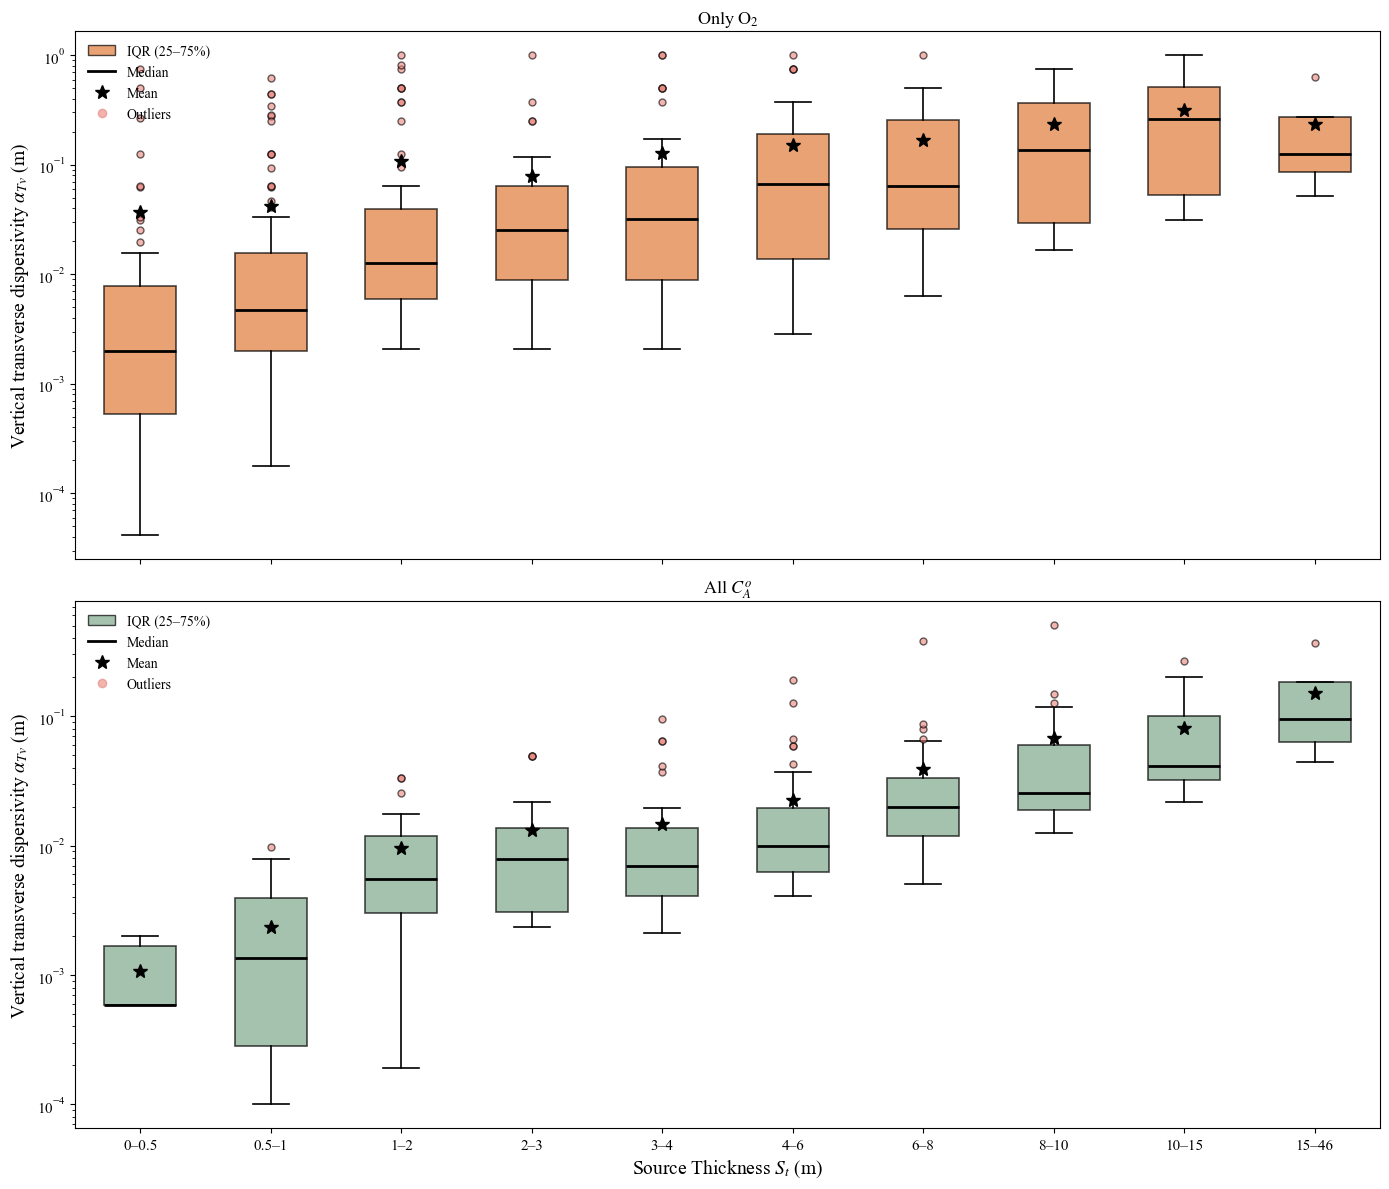


 O₂ + O₂N — All Sites (pooled across all φ) (TV)
Bin              N       Min        Q1    Median      Mean       Std        Q3       Max
----------------------------------------------------------------------------------------------------
0–0.5           54    0.0000    0.0005    0.0020    0.0371    0.1254    0.0079    0.7485
0.5–1           92    0.0002    0.0020    0.0047    0.0420    0.1064    0.0157    0.6245
1–2             54    0.0021    0.0060    0.0128    0.1082    0.2264    0.0391    0.9980
2–3             36    0.0021    0.0089    0.0254    0.0790    0.1767    0.0643    0.9980
3–4             42    0.0021    0.0088    0.0322    0.1270    0.2386    0.0955    0.9980
4–6             48    0.0028    0.0137    0.0662    0.1519    0.2249    0.1905    0.9980
6–8             33    0.0063    0.0259    0.0641    0.1671    0.2125    0.2571    0.9980
8–10            18    0.0166    0.0294    0.1374    0.2345    0.2456    0.3651    0.7510
10–15           16    0.0314    0.0530    0.2616

In [6]:
# ---------------------------------------------------------------------------
# Load & Clean function for all phi sheets
# ---------------------------------------------------------------------------
PHIS      = ["0.1", "0.2", "0.4", "0.5", "0.6", "0.8", "1.0"]   # O2 / All
PHIS_O2N  = ["0.1", "0.25", "0.5", "0.75", "1.0"]               # O2N
PHIS_ALLN = ["0.5", "0.75", "1.0"]                               # AllN

COLOR_O2      = "#E07B39"   # orange     → O2 panel
COLOR_ALL     = "#7FA88E"   # sage-green → All panel
COLOR_OUTLIER = "#E8827A"   # salmon-pink

# ---------------------------------------------------------------------------
# Thickness bins
# ---------------------------------------------------------------------------
BIN_EDGES = [0, 0.5, 1, 2, 3, 4, 6, 8, 10, 15, 46]

BIN_LABELS = [
    "0–0.5", "0.5–1", "1–2", "2–3", "3–4",
    "4–6", "6–8", "8–10", "10–15", "15–46"
]

# ---------------------------------------------------------------------------
# Clean function
# ---------------------------------------------------------------------------
def clean(df):
    df = df.copy()

    df["Site_ID"] = pd.to_numeric(df["Site_ID"], errors="coerce")
    df["st"]  = pd.to_numeric(df["st"],  errors="coerce")
    df["atv"] = pd.to_numeric(df["atv"], errors="coerce")

    df = df.dropna(subset=["Site_ID", "st", "atv"])
    df = df[(df["st"] > 0) & (df["atv"] > 0)]
    df["Site_ID"] = df["Site_ID"].astype(int)

    return df.reset_index(drop=True)


# ---------------------------------------------------------------------------
# Generic loader: reads & pools every f"{phi}_{suffix}" sheet in a phi list
# ---------------------------------------------------------------------------
def load_pool(phi_list, suffix):
    frames = []
    for phi in phi_list:
        df = clean(
            pd.read_excel(EXCEL_PATH_TV, sheet_name=f"{phi}_{suffix}")
        )
        print(f"{phi}_{suffix}: N_sites={df['Site_ID'].nunique()}, N_rows={len(df)}")
        frames.append(df)

    return pd.concat(frames, ignore_index=True)


# ---------------------------------------------------------------------------
# Load and MERGE O2 + O2N into one pool, All + AllN into one pool
# ---------------------------------------------------------------------------
df_o2_only   = load_pool(PHIS,      "O2")
df_o2n_only  = load_pool(PHIS_O2N,  "O2N")
df_all_only  = load_pool(PHIS,      "All")
df_alln_only = load_pool(PHIS_ALLN, "AllN")

# merge: O2 + O2N together as ONE dataset
df_o2_pool = pd.concat([df_o2_only, df_o2n_only], ignore_index=True)

# merge: All + AllN together as ONE dataset
df_all_pool = pd.concat([df_all_only, df_alln_only], ignore_index=True)

print(f"\nMerged O2 (+O2N): N_sites={df_o2_pool['Site_ID'].nunique()}, N_rows={len(df_o2_pool)}")
print(f"Merged All (+AllN): N_sites={df_all_pool['Site_ID'].nunique()}, N_rows={len(df_all_pool)}")

# ---------------------------------------------------------------------------
# Assign bins
# ---------------------------------------------------------------------------
df_o2_pool["bin"] = pd.cut(df_o2_pool["st"], bins=BIN_EDGES, labels=BIN_LABELS)
df_all_pool["bin"] = pd.cut(df_all_pool["st"], bins=BIN_EDGES, labels=BIN_LABELS)


# ---------------------------------------------------------------------------
# Plot function (same as your original single-box-per-bin version)
# ---------------------------------------------------------------------------
def plot_boxplot(ax, df_pool, title, ylabel, box_color):

    data_per_bin = []
    labels_used = []

    for lbl in BIN_LABELS:
        vals = df_pool.loc[df_pool["bin"] == lbl, "atv"].dropna().values
        if len(vals) > 0:
            data_per_bin.append(vals)
            labels_used.append(lbl)

    positions = np.arange(1, len(labels_used) + 1)

    bp = ax.boxplot(
        data_per_bin,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2),
        flierprops=dict(
            marker="o", color=COLOR_OUTLIER, markerfacecolor=COLOR_OUTLIER,
            alpha=0.6, markersize=5, linestyle="none"
        ),
        boxprops=dict(linewidth=1.2)
    )

    for patch in bp["boxes"]:
        patch.set_facecolor(box_color)
        patch.set_alpha(0.7)

    for i, vals in enumerate(data_per_bin):
        ax.plot(positions[i], np.mean(vals), marker="*", color="black",
                 markersize=10, zorder=5)

    ax.set_yscale("log")
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=13)
    ax.tick_params(axis="both", labelsize=11)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels_used, rotation=0, fontsize=11)

    legend_elements = [
        mpatches.Patch(facecolor=box_color, edgecolor="black", alpha=0.7, label="IQR (25–75%)"),
        mlines.Line2D([0], [0], color="black", linewidth=2, label="Median"),
        mlines.Line2D([0], [0], marker="*", color="black", linestyle="none", markersize=10, label="Mean"),
        mlines.Line2D([0], [0], marker="o", color=COLOR_OUTLIER, markerfacecolor=COLOR_OUTLIER,
                       linestyle="none", markersize=6, alpha=0.6, label="Outliers")
    ]
    ax.legend(handles=legend_elements, frameon=False, loc="upper left", fontsize=10)


# ---------------------------------------------------------------------------
# Create figure — 2 panels, each merged (O2+O2N) and (All+AllN)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

plot_boxplot(
    axes[0], df_o2_pool,
    title=r"Only O$_2$",
    ylabel=r"Vertical transverse dispersivity $\alpha_{Tv}$ (m)",
    box_color=COLOR_O2
)

plot_boxplot(
    axes[1], df_all_pool,
    title=r"All $C_A^o$",
    ylabel=r"Vertical transverse dispersivity $\alpha_{Tv}$ (m)",
    box_color=COLOR_ALL
)

axes[1].set_xlabel(r"Source Thickness $S_t$ (m)", fontsize=14)

plt.tight_layout()
plt.savefig("S4.pdf", dpi=300)
plt.show()


# ---------------------------------------------------------------------------
# Statistics table
# ---------------------------------------------------------------------------
def print_stats(df_pool, label):
    print(f"\n{'='*100}")
    print(f" {label}")
    print(f"{'='*100}")
    print(
        f"{'Bin':<12}{'N':>6}{'Min':>10}{'Q1':>10}{'Median':>10}"
        f"{'Mean':>10}{'Std':>10}{'Q3':>10}{'Max':>10}"
    )
    print("-"*100)

    for lbl in BIN_LABELS:
        vals = df_pool.loc[df_pool["bin"] == lbl, "atv"].dropna().values
        if len(vals) == 0:
            continue

        q1, median, q3 = np.percentile(vals, [25, 50, 75])
        std = vals.std(ddof=1) if len(vals) > 1 else np.nan

        print(
            f"{lbl:<12}{len(vals):>6}{vals.min():>10.4f}{q1:>10.4f}"
            f"{median:>10.4f}{vals.mean():>10.4f}{std:>10.4f}"
            f"{q3:>10.4f}{vals.max():>10.4f}"
        )

    print(f"{'='*100}")


print_stats(df_o2_pool,  "O₂ + O₂N — All Sites (pooled across all φ) (TV)")
print_stats(df_all_pool, "All C_A° + AllN — All Sites (pooled across all φ) (TV)")

In [7]:


# MAKE SURE TO CHANGE THE PATHS BELOW TO THE LOCATION OF YOUR EXCEL FILES

sheet_names = pd.ExcelFile(r"C:\Users\mouly\Dropbox\Codes and Dataset\Field_Vertical.xlsx").sheet_names

dfs = pd.read_excel(
    r"C:\Users\mouly\Dropbox\Codes and Dataset\Field_Vertical.xlsx",
    sheet_name=sheet_names[:7],
    usecols=["aq", "st", "atv"]

)

for name, df in dfs.items():
    for col in ["aq", "st", "atv"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

        df = df.dropna(subset=["aq", "atv"])

    df["aq"] = df["aq"]*2 # multiplying to get the exact Aquifer thickness
    dfs[name] = df


# removing aquifer thickness > 50 m
for name, df in dfs.items():
    dfs[name] = df[df["aq"] <= 50]

# ----  load the "All" sheets too ----
dfs_all = pd.read_excel(
    r"C:\Users\mouly\Dropbox\Codes and Dataset\Field_Vertical.xlsx",
    sheet_name=sheet_names[7:14],
    usecols=["aq", "st", "atv"]
)
for name, df in dfs_all.items():
    for col in ["aq", "st", "atv"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df = df.dropna(subset=["aq", "atv"])
    df["aq"] = df["aq"]*2
    dfs_all[name] = df
for name, df in dfs_all.items():
    dfs_all[name] = df[df["aq"] <= 50]



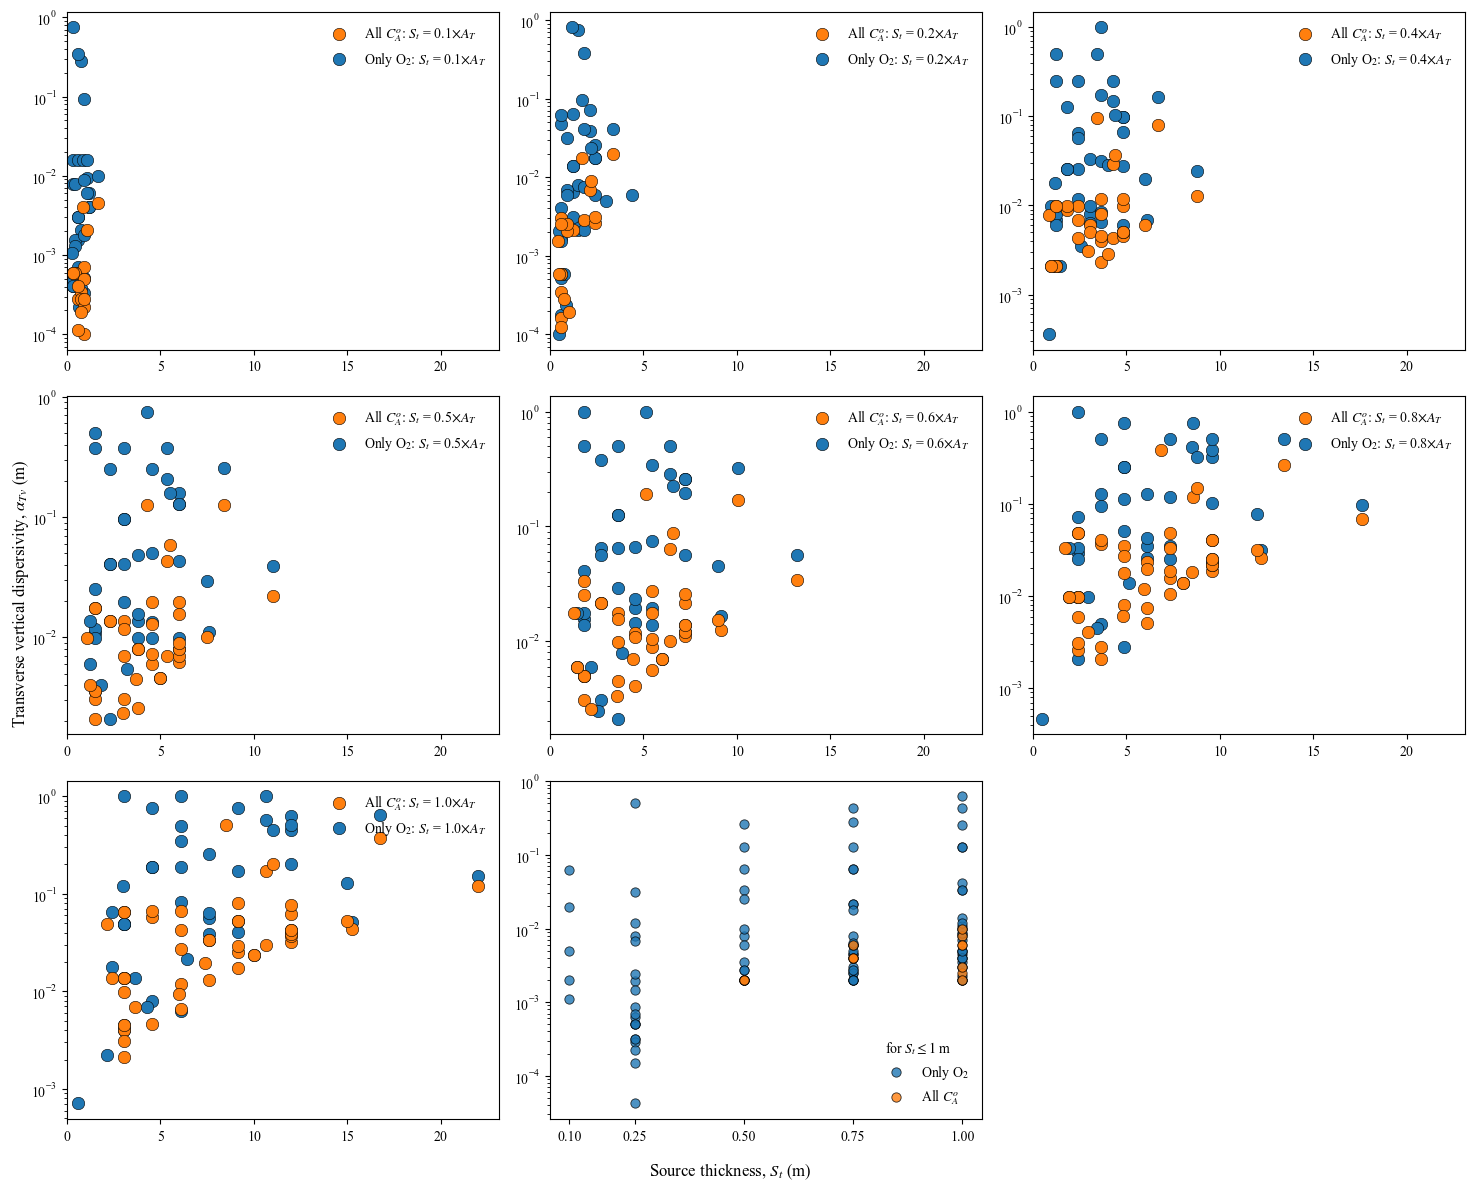

In [8]:
import math

# -------------------------------------------------------------------------
# Colors (matplotlib default blue/orange, matching your existing figure)
# -------------------------------------------------------------------------
COLOR_O2  = "tab:blue"
COLOR_ALL = "tab:orange"

n = len(dfs)
ncols = 3
nrows = math.ceil((n + 1) / ncols)   # +1 to make room for the extra N-panel

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 4 * nrows)
)

# use the TRUE max across BOTH O2 and All sheets
global_xmax = max(
    max(df["st"].max() for df in dfs.values()),
    max(df["st"].max() for df in dfs_all.values())
)

axes = axes.flatten()

# ----------------------------------------------------------------------
# Main plotting loop, one panel per phi sheet
# ----------------------------------------------------------------------
for ax, (sheet_name, df) in zip(axes, dfs.items()):
    # phi value pulled from the sheet name, e.g. "0.1_O2" -> "0.1"
    phi = sheet_name.split("_")[0]
    # matching "All" sheet for this same phi
    all_name = list(dfs_all.keys())[list(dfs.keys()).index(sheet_name)]
    df_all = dfs_all[all_name]

    n_o2  = len(df)
    n_all = len(df_all)

    # ---- scatter points ----
    ax.scatter(
        df["st"], df["atv"],
        color=COLOR_O2, edgecolors="black", linewidths=0.4, s=80,
        label=rf"Only O$_2$: $S_t$ = {phi}$\times A_T$",
    )
    ax.scatter(
        df_all["st"], df_all["atv"],
        color=COLOR_ALL, edgecolors="black", linewidths=0.4, s=80,
        label=rf"All $C_A^o$: $S_t$ = {phi}$\times A_T$",
    )

    # ---- legend box, "All" first then "Only O2" (matches target image order) ----
    handles, labels = ax.get_legend_handles_labels()
    order = [1, 0]   # swap so "All" appears above "Only O2"
    ax.legend(
        [handles[i] for i in order], [labels[i] for i in order],
        loc="upper right", frameon=False, fontsize=10,
    )
    ax.set_xlim(0, global_xmax * 1.05)
    ax.set_yscale("log")

# ----------------------------------------------------------------------
# 8th panel: N-series aggregated scatter (goes right after the phi panels)
# ----------------------------------------------------------------------
FRACTIONS_O2N  = ["0.1", "0.25", "0.5", "0.75", "1.0"]
FRACTIONS_ALLN = ["0.5", "0.75", "1.0"]

def load_N(suffix, fractions):
    frames = []
    for frac in fractions:
        df = pd.read_excel(EXCEL_PATH_TV, sheet_name=f"{frac}_{suffix}")[["st", "atv"]]
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    out["st"]  = pd.to_numeric(out["st"], errors="coerce")
    out["atv"] = pd.to_numeric(out["atv"], errors="coerce")
    return out.dropna(subset=["st", "atv"])

o2n  = load_N("O2N",  FRACTIONS_O2N)
alln = load_N("AllN", FRACTIONS_ALLN)

ax_n = axes[n]  # the 8th subplot (index 7 when there are 7 phi sheets)

ax_n.scatter(o2n["st"], o2n["atv"], s=45, color=COLOR_O2, edgecolors="black",
             linewidths=0.6, alpha=0.8, label="Only O$_2$")
ax_n.scatter(alln["st"], alln["atv"], s=45, color=COLOR_ALL, edgecolors="black",
             linewidths=0.6, alpha=0.8, label="All $C_A^o$")

ax_n.text(0.9, 10**(-3.5), r"for $S_t \leq 1$ m", ha="center", va="top",  )
ax_n.set_yscale("log")
ax_n.set_xticks([0.1, 0.25, 0.5, 0.75, 1.0])
ax_n.legend(frameon=False)

# Hide unused axes (everything after the N-panel)
for ax in axes[n + 1:]:
    ax.set_visible(False)

fig.supxlabel(r"Source thickness, $S_t$ (m)")
fig.supylabel(r"Transverse vertical dispersivity, $\alpha_{Tv}$ (m)")
plt.tight_layout()
plt.savefig("S5.pdf", dpi=300)
plt.show()

phi = 0.1: All=30 sites, O2=40 sites
phi = 0.25: All=36 sites, O2=45 sites
phi = 0.5: All=39 sites, O2=42 sites
phi = 0.75: All=37 sites, O2=36 sites
phi = 1.0: All=42 sites, O2=31 sites
phi = 1.5: All=33 sites, O2=26 sites
phi = 2.0: All=32 sites, O2=25 sites


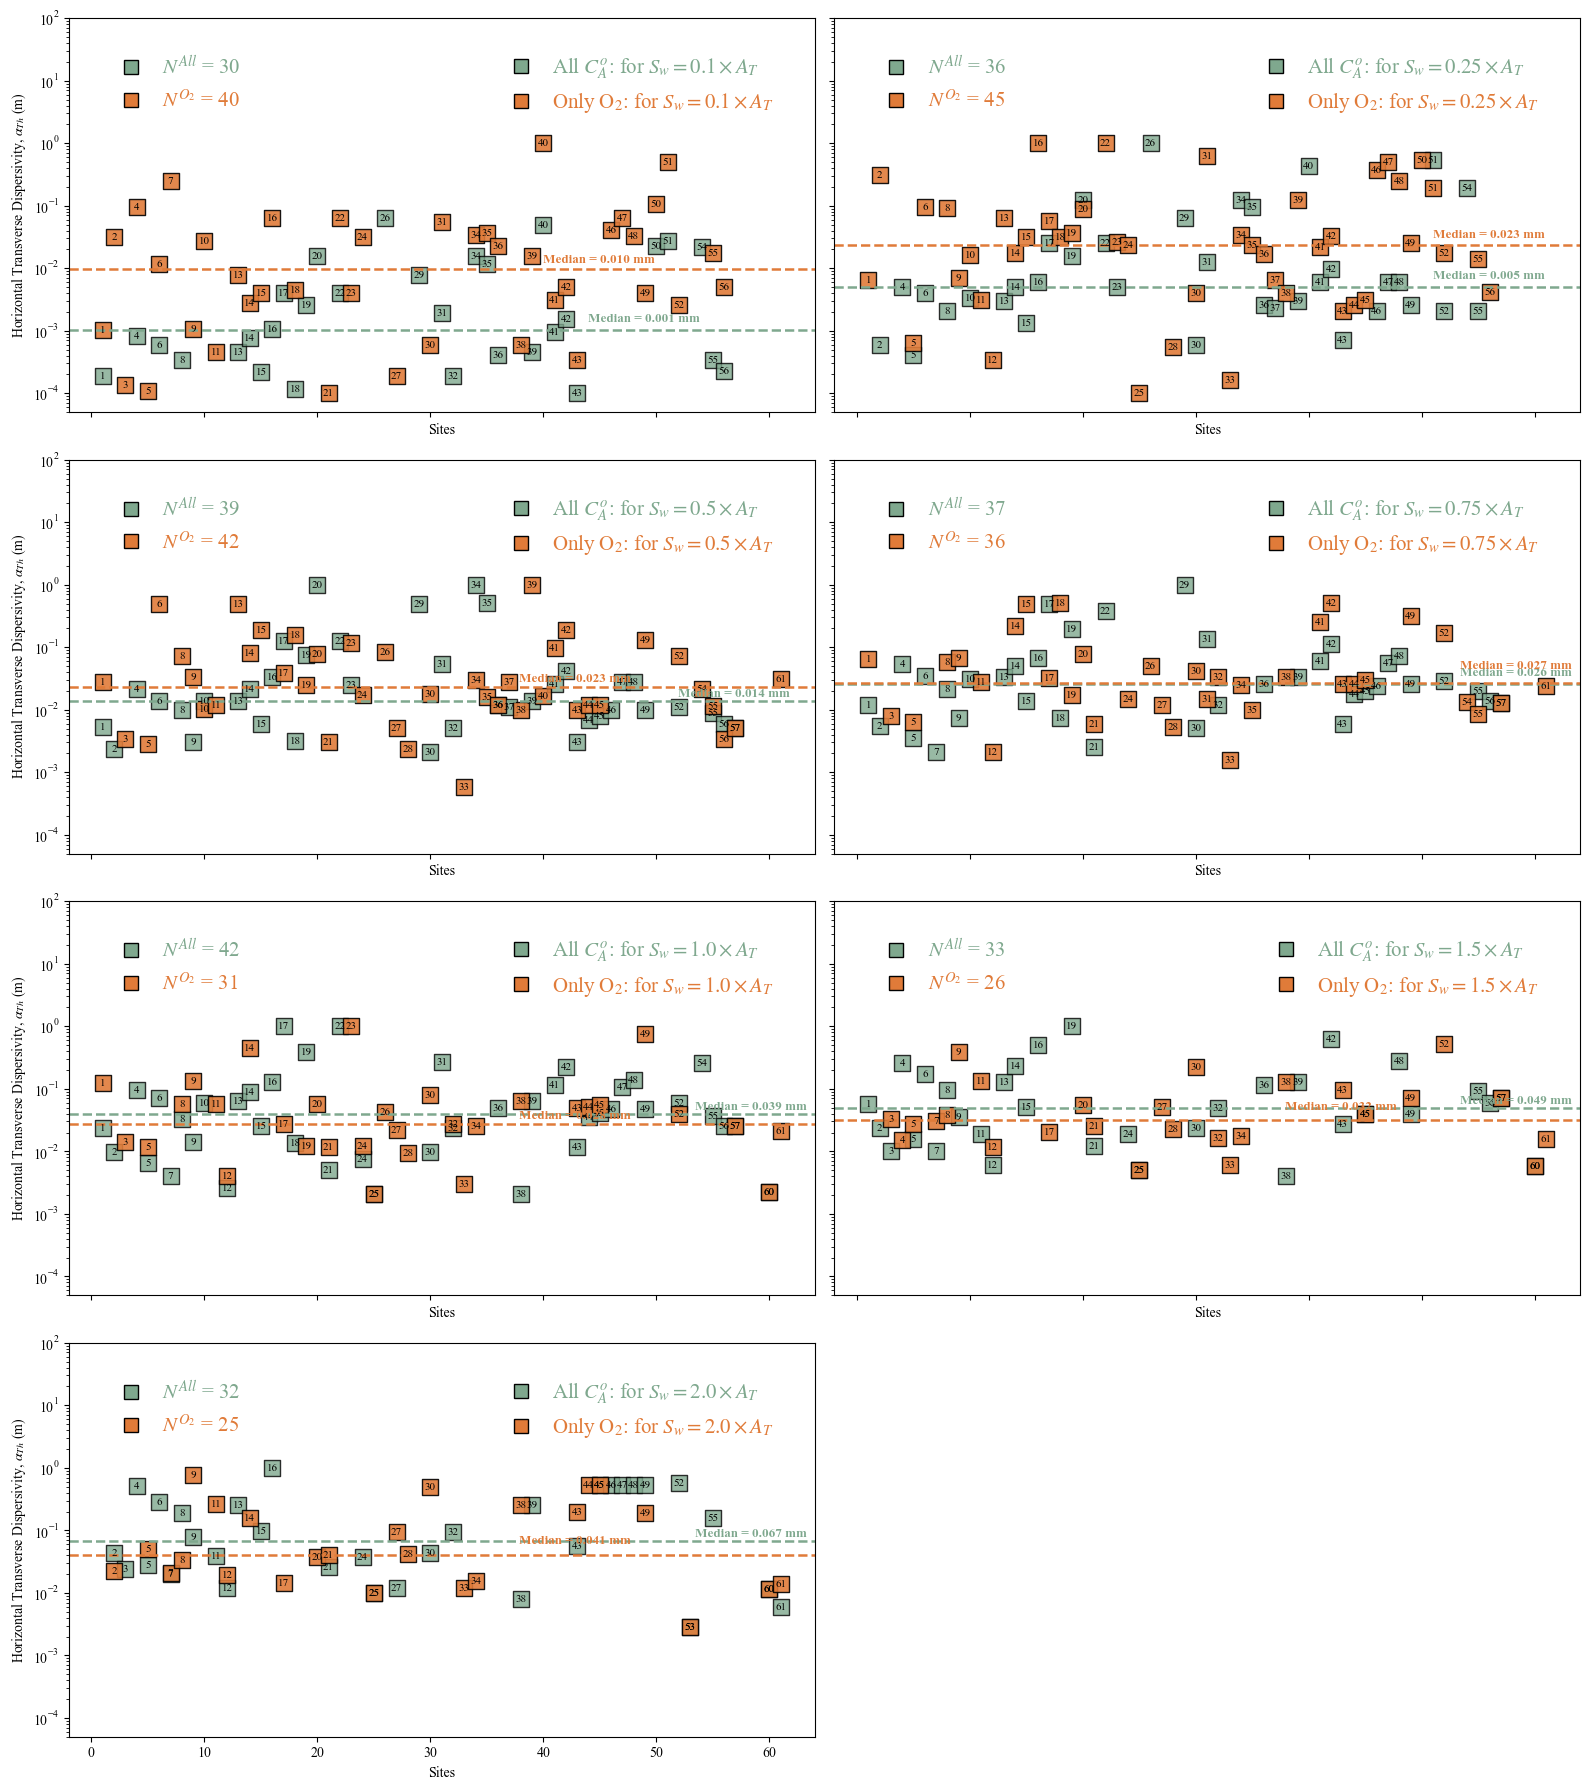

In [9]:
#HORIZONTAL

# ---------------------------------------------------------------------------
# Load Data
# ---------------------------------------------------------------------------
PHIS = [ "0.1", "0.25", "0.5", "0.75", "1.0", "1.5", "2.0"]

COLOR_O2      = "#E07B39"   # orange  → O2 panel
COLOR_ALL     = "#7FA88E"   # sage-green → All panel
COLOR_OUTLIER = "#E8827A"   # salmon-pink

N_ROWS, N_COLS = 4, 2  # 7 panels -> clean 4x2 grid 

# ---------------------------------------------------------------------------
# Position of the Median text
# Format: phi -> (dx_all, dy_mult_all, dx_o2, dy_mult_o2)
# ---------------------------------------------------------------------------
LABEL_OFFSETS = {
    "0.1": (-1, 1.2, -5, 1.1),
    "0.25": (6, 1.2, 6, 1.2),
    "0.5": (2, 1.05, -12, 1.05),
    "0.75": (3.5, 1.2, 3.5, 1.5),
    "1.0": (3.5, 1.05, -12, 1.05),
    "1.5": (3.5, 1.05, -12, 1.3),
    "2.0": (3.5, 1.05, -12, 1.3),
}

# ---------------------------------------------------------------------------
# Figure setup
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(16, 18), sharex=True, sharey=True)
axes = axes.flatten()

for i, phi in enumerate(PHIS):
    ax = axes[i]
    # -----------------------------------------------------------------
    # Load datasets for this phi
    # -----------------------------------------------------------------
    sheet_all = f"{phi}_All"
    sheet_o2  = f"{phi}_O2"
    df_all = pd.read_excel(EXCEL_PATH_TH, sheet_name=sheet_all)
    df_o2  = pd.read_excel(EXCEL_PATH_TH, sheet_name=sheet_o2)
    # -----------------------------------------------------------------
    # Clean data
    # -----------------------------------------------------------------
    for df in [df_all, df_o2]:
        df["Site_ID"] = pd.to_numeric(df["Site_ID"], errors="coerce")
        df["ath"]   = pd.to_numeric(df["ath"],   errors="coerce")
        df.dropna(subset=["Site_ID", "ath"], inplace=True)
        df["Site_ID"] = df["Site_ID"].astype(int)
    # -----------------------------------------------------------------
    # Site counts
    # -----------------------------------------------------------------
    n_all_sites = df_all["Site_ID"].nunique()
    n_o2_sites  = df_o2["Site_ID"].nunique()
    print(f"phi = {phi}: All={n_all_sites} sites, O2={n_o2_sites} sites")
    # -----------------------------------------------------------------
    # Medians
    # -----------------------------------------------------------------
    median_all = df_all["ath"].median()
    median_o2  = df_o2["ath"].median()
    # -----------------------------------------------------------------
    # Plot
    # -----------------------------------------------------------------
    ax.scatter(
        df_all["Site_ID"], df_all["ath"],
        color=COLOR_ALL, edgecolors="black",
        marker="s", s=120,
        alpha=0.8
    )
    ax.scatter(
        df_o2["Site_ID"], df_o2["ath"],
        color=COLOR_O2, edgecolors="black",
        marker="s", s=120,
        alpha=0.9
    )
    # Site labels
    for _, row in df_all.iterrows():
        ax.text(row["Site_ID"], row["ath"], str(int(row["Site_ID"])),
                 ha="center", va="center", fontsize=8, color="black")
    for _, row in df_o2.iterrows():
        ax.text(row["Site_ID"], row["ath"], str(int(row["Site_ID"])),
                 ha="center", va="center", fontsize=8, color="black")
    # -----------------------------------------------------------------
    # Median lines
    # -----------------------------------------------------------------
    ax.axhline(median_all, color=COLOR_ALL, linestyle="--", linewidth=1.8, zorder=1)
    ax.axhline(median_o2,  color=COLOR_O2, linestyle="--", linewidth=1.8, zorder=1)

    xmax = max(df_all["Site_ID"].max(), df_o2["Site_ID"].max())
    dx_all, dy_all, dx_o2, dy_o2 = LABEL_OFFSETS.get(phi, (0, 1.3, 0, 1.3))

    ax.text(
        xmax * 0.98 + dx_all, median_all * dy_all,
        f"Median = {median_all:.3f} mm",
        color=COLOR_ALL, fontsize=9.5, fontweight="bold",
        ha="right", va="bottom"
    )
    ax.text(
        xmax * 0.98 + dx_o2, median_o2 * dy_o2,
        f"Median = {median_o2:.3f} mm",
        color=COLOR_O2, fontsize=9.5, fontweight="bold",
        ha="right", va="bottom"
    )
    # -----------------------------------------------------------------
    # Formatting (per-panel)
    # -----------------------------------------------------------------
    ax.set_yscale("log")
    ax.set_ylim(5e-5, 100)
    col = i % N_COLS
    row = i // N_COLS
    if col == 0:
        ax.set_ylabel(r"Horizontal Transverse Dispersivity, $\alpha_{Th}$ (m)")
    else:
        ax.tick_params(labelleft=False)
    ax.set_xlabel("Sites")

    # -----------------------------------------------------------------
    # RIGHT legend
    # -----------------------------------------------------------------
    handles_right = [
        mlines.Line2D([], [], color=COLOR_ALL, marker="s", markeredgecolor="black",
                      markersize=10, linestyle="None",
                      label=rf"All $C_A^o$: for $S_w={phi}\times A_T$"),
        mlines.Line2D([], [], color=COLOR_O2, marker="s", markeredgecolor="black",
                      markersize=10, linestyle="None",
                      label=rf"Only O$_2$: for $S_w={phi}\times A_T$"),
    ]
    leg_right = ax.legend(
        handles=handles_right,
        loc="upper right", bbox_to_anchor=(0.97, 0.95),
        frameon=False, handletextpad=0.5, labelspacing=0.5,
        fontsize=15
    )
    for text, color in zip(leg_right.get_texts(), [COLOR_ALL, COLOR_O2]):
        text.set_color(color)

    # -----------------------------------------------------------------
    # LEFT legend: N counts only
    # -----------------------------------------------------------------
    handles_left = [
        mlines.Line2D([], [], color=COLOR_ALL, marker="s", markeredgecolor="black",
                      markersize=10, linestyle="None",
                      label=rf"$N^{{All}}$ = {n_all_sites}"),
        mlines.Line2D([], [], color=COLOR_O2, marker="s", markeredgecolor="black",
                      markersize=10, linestyle="None",
                      label=rf"$N^{{O_2}}$ = {n_o2_sites}"),
    ]
    leg_left = ax.legend(
        handles=handles_left,
        loc="upper left", bbox_to_anchor=(0.03, 0.95),
        frameon=False, handletextpad=0.5, labelspacing=0.5,
        fontsize=15
    )
    for text, color in zip(leg_left.get_texts(), [COLOR_ALL, COLOR_O2]):
        text.set_color(color)

    # Re-add right legend (adding second legend removes first by default)
    ax.add_artist(leg_right)

    # ---------------------------------------------------------------------------
# Hide any unused subplot axes (when len(PHIS) < N_ROWS * N_COLS)
# ---------------------------------------------------------------------------
for j in range(len(PHIS), N_ROWS * N_COLS):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("S6.pdf", dpi=300)
plt.show()

0.1: O2=40, All=30
0.25: O2=45, All=36
0.5: O2=42, All=39
0.75: O2=36, All=37
1.0: O2=31, All=42
1.5: O2=26, All=33
2.0: O2=25, All=32


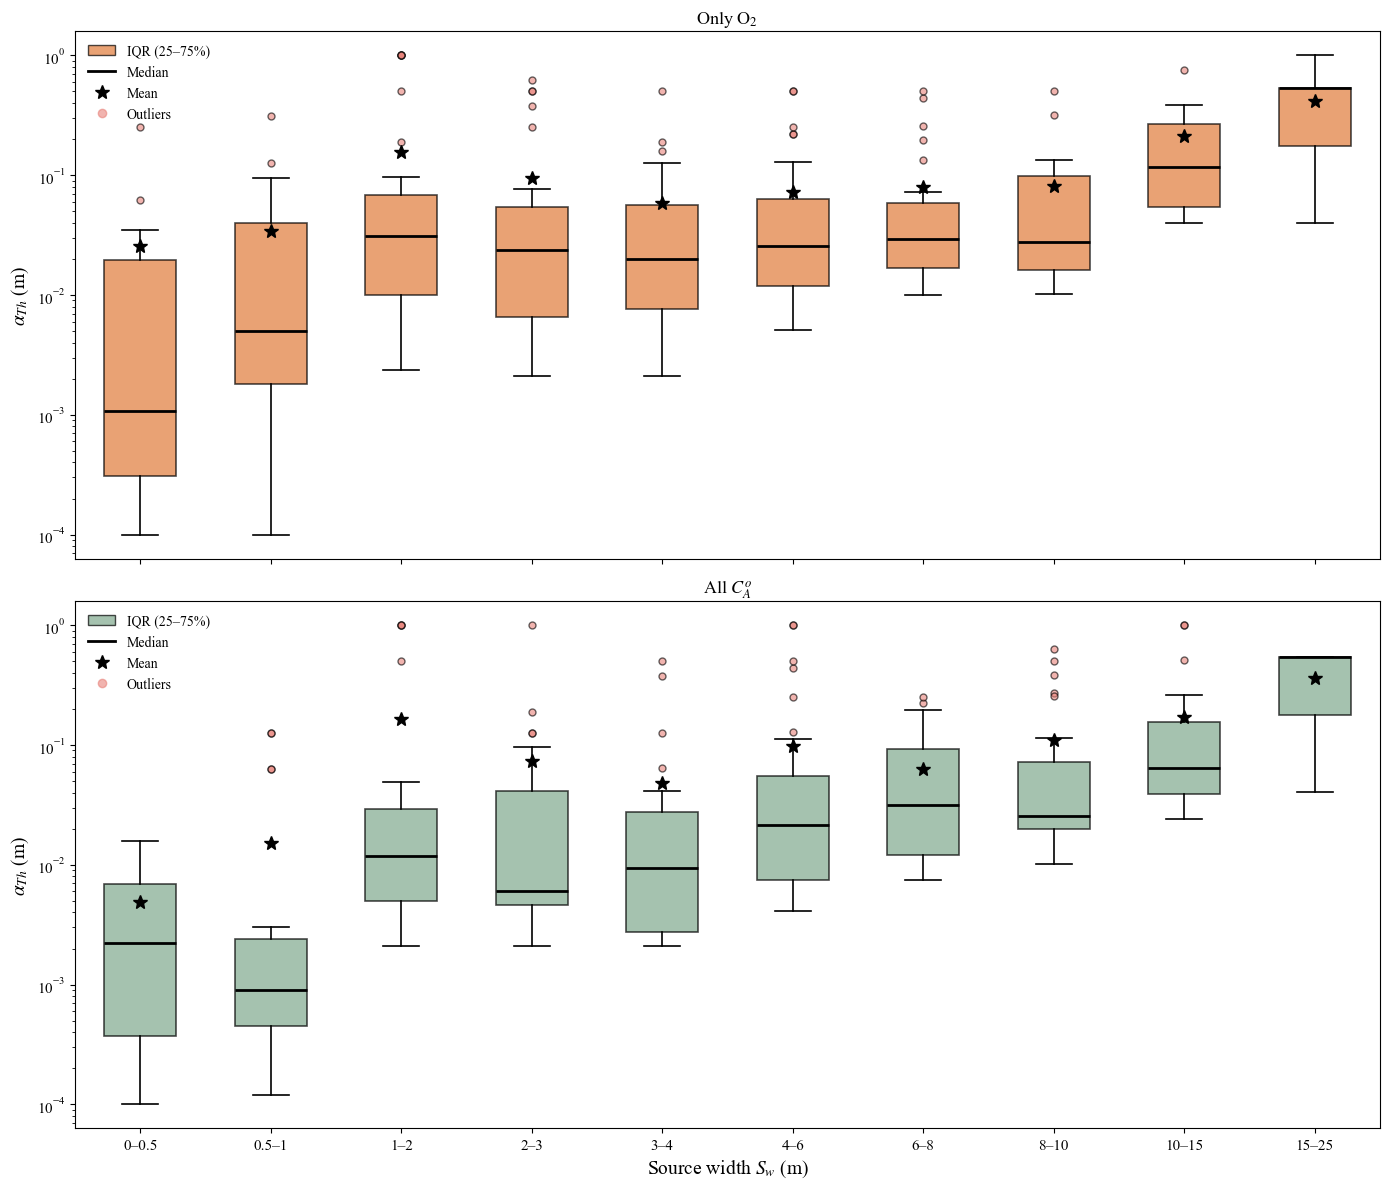


 Only O₂ — All Sites (pooled across all φ) [Th]
Bin              N       Min        Q1    Median      Mean       Std        Q3       Max
----------------------------------------------------------------------------------------------------
0–0.5           16    0.0001    0.0003    0.0011    0.0257    0.0624    0.0196    0.2501
0.5–1           32    0.0001    0.0018    0.0050    0.0340    0.0614    0.0396    0.3126
1–2             35    0.0023    0.0099    0.0310    0.1568    0.3193    0.0689    1.0000
2–3             30    0.0021    0.0065    0.0237    0.0939    0.1719    0.0539    0.6258
3–4             26    0.0021    0.0077    0.0201    0.0585    0.1030    0.0566    0.5010
4–6             38    0.0051    0.0119    0.0258    0.0718    0.1200    0.0635    0.5020
6–8             28    0.0099    0.0169    0.0292    0.0797    0.1250    0.0584    0.5020
8–10            20    0.0101    0.0161    0.0276    0.0804    0.1244    0.0985    0.5080
10–15            9    0.0401    0.0545    0.1160 

In [10]:
# ---------------------------------------------------------------------------
# Load
# ---------------------------------------------------------------------------
PHIS = ["0.1", "0.25", "0.5", "0.75", "1.0", "1.5", "2.0"]

COLOR_O2      = "#E07B39"   # orange  → O2 panel
COLOR_ALL     = "#7FA88E"   # sage-green → All panel
COLOR_OUTLIER = "#E8827A"   # salmon-pink

# ---------------------------------------------------------------------------
# Thickness bins
# ---------------------------------------------------------------------------
BIN_EDGES = [0, 0.5, 1, 2, 3, 4, 6, 8, 10, 15, 25]

BIN_LABELS = [
    "0–0.5", "0.5–1", "1–2", "2–3", "3–4",
    "4–6", "6–8", "8–10", "10–15", "15–25"
]

# ---------------------------------------------------------------------------
# Clean function
# ---------------------------------------------------------------------------
def clean(df):
    df = df.copy()

    df["Site_ID"] = pd.to_numeric(
        df["Site_ID"], errors="coerce"
    )
    df["st"] = pd.to_numeric(
        df["st"], errors="coerce"
    )
    df["ath"] = pd.to_numeric(
        df["ath"], errors="coerce"
    )

    df = df.dropna(
        subset=["Site_ID", "st", "ath"]
    )

    df = df[
        (df["st"] > 0) &
        (df["ath"] > 0)
    ]

    df["Site_ID"] = df["Site_ID"].astype(int)

    return df.reset_index(drop=True)


# ---------------------------------------------------------------------------
# Load ALL sites (UNFILTERED)
# ---------------------------------------------------------------------------
o2_list  = []
all_list = []

for phi in PHIS:

    df_o2 = clean(
        pd.read_excel(
            EXCEL_PATH_TH,
            sheet_name=f"{phi}_O2"
        )
    )

    df_all = clean(
        pd.read_excel(
            EXCEL_PATH_TH,
            sheet_name=f"{phi}_All"
        )
    )

    print(
        f"{phi}: "
        f"O2={df_o2['Site_ID'].nunique()}, "
        f"All={df_all['Site_ID'].nunique()}"
    )

    # Keep everything (no common-site filtering)
    o2_list.append(df_o2)
    all_list.append(df_all)


# ---------------------------------------------------------------------------
# Pool all phi values
# ---------------------------------------------------------------------------
df_o2_pool = pd.concat(
    o2_list,
    ignore_index=True
)

df_all_pool = pd.concat(
    all_list,
    ignore_index=True
)


# ---------------------------------------------------------------------------
# Assign bins
# ---------------------------------------------------------------------------
df_o2_pool["bin"] = pd.cut(
    df_o2_pool["st"],
    bins=BIN_EDGES,
    labels=BIN_LABELS
)

df_all_pool["bin"] = pd.cut(
    df_all_pool["st"],
    bins=BIN_EDGES,
    labels=BIN_LABELS
)


# ---------------------------------------------------------------------------
# Plot function
# ---------------------------------------------------------------------------
def plot_boxplot(ax, df_pool, title, ylabel, box_color):

    data_per_bin = []
    labels_used = []

    for lbl in BIN_LABELS:

        vals = (
            df_pool.loc[
                df_pool["bin"] == lbl,
                "ath"
            ]
            .dropna()
            .values
        )

        if len(vals) > 0:
            data_per_bin.append(vals)
            labels_used.append(lbl)

    positions = np.arange(
        1,
        len(labels_used) + 1
    )

    bp = ax.boxplot(
        data_per_bin,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=True,

        medianprops=dict(
            color="black",
            linewidth=2
        ),

        whiskerprops=dict(
            color="black",
            linewidth=1.2
        ),

        capprops=dict(
            color="black",
            linewidth=1.2
        ),

        flierprops=dict(
            marker="o",
            color=COLOR_OUTLIER,
            markerfacecolor=COLOR_OUTLIER,
            alpha=0.6,
            markersize=5,
            linestyle="none"
        ),

        boxprops=dict(
            linewidth=1.2
        )
    )

    # Fill box colors
    for patch in bp["boxes"]:
        patch.set_facecolor(box_color)
        patch.set_alpha(0.7)

    # Plot mean stars
    for i, vals in enumerate(data_per_bin):

        ax.plot(
            positions[i],
            np.mean(vals),
            marker="*",
            color="black",
            markersize=10,
            zorder=5
        )

    ax.set_yscale("log")

    ax.set_ylabel(
        ylabel,
        fontsize=14
    )

    ax.set_title(
        title,
        fontsize=13
    )

    ax.tick_params(
        axis="both",
        labelsize=11
    )

    ax.set_xticks(positions)

    ax.set_xticklabels(
        labels_used,
        rotation=0,
        fontsize=11
    )

    legend_elements = [

        mpatches.Patch(
            facecolor=box_color,
            edgecolor="black",
            alpha=0.7,
            label="IQR (25–75%)"
        ),

        mlines.Line2D(
            [0], [0],
            color="black",
            linewidth=2,
            label="Median"
        ),

        mlines.Line2D(
            [0], [0],
            marker="*",
            color="black",
            linestyle="none",
            markersize=10,
            label="Mean"
        ),

        mlines.Line2D(
            [0], [0],
            marker="o",
            color=COLOR_OUTLIER,
            markerfacecolor=COLOR_OUTLIER,
            linestyle="none",
            markersize=6,
            alpha=0.6,
            label="Outliers"
        )
    ]

    ax.legend(
        handles=legend_elements,
        frameon=False,
        loc="upper left",
        fontsize=10
    )


# ---------------------------------------------------------------------------
# Create figure
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14,12),
    sharex=True
)

# Top panel
plot_boxplot(
    axes[0],
    df_o2_pool,
    title=r"Only O$_2$ ",
    ylabel=r"$\alpha_{Th}$ (m)",
    box_color=COLOR_O2
)

# Bottom panel
plot_boxplot(
    axes[1],
    df_all_pool,
    title=r"All $C_A^o$",
    ylabel=r"$\alpha_{Th}$ (m)",
    box_color=COLOR_ALL
)

axes[1].set_xlabel(
    r"Source width $S_w$ (m)",
    fontsize=14
)

plt.tight_layout()
plt.savefig("S7.pdf",dpi=300)
plt.show()

# ---------------------------------------------------------------------------
# Statistics table
# ---------------------------------------------------------------------------
def print_stats(df_pool, label):

    print(f"\n{'='*100}")
    print(f" {label}")
    print(f"{'='*100}")

    print(
        f"{'Bin':<12}"
        f"{'N':>6}"
        f"{'Min':>10}"
        f"{'Q1':>10}"
        f"{'Median':>10}"
        f"{'Mean':>10}"
        f"{'Std':>10}"
        f"{'Q3':>10}"
        f"{'Max':>10}"
    )

    print("-"*100)

    for lbl in BIN_LABELS:

        vals = (
            df_pool.loc[
                df_pool["bin"] == lbl,
                "ath"
            ]
            .dropna()
            .values
        )

        if len(vals) == 0:
            continue

        q1, median, q3 = np.percentile(
            vals,
            [25, 50, 75]
        )

        std = vals.std(ddof=1) if len(vals) > 1 else np.nan  # sample std

        print(
            f"{lbl:<12}"
            f"{len(vals):>6}"
            f"{vals.min():>10.4f}"
            f"{q1:>10.4f}"
            f"{median:>10.4f}"
            f"{vals.mean():>10.4f}"
            f"{std:>10.4f}"
            f"{q3:>10.4f}"
            f"{vals.max():>10.4f}"
        )

    print(f"{'='*100}")


print_stats(
    df_o2_pool,
    "Only O₂ — All Sites (pooled across all φ) [Th]"
)

print_stats(
    df_all_pool,
    "All C_A° — All Sites (pooled across all φ) [Th]"
)

In [11]:

#make sure to change the paths below to the location of your Excel files

sheet_names = pd.ExcelFile( r"C:\Users\mouly\Dropbox\Codes and Dataset\Field_Horizontal.xlsx").sheet_names

dfs = pd.read_excel(
     r"C:\Users\mouly\Dropbox\Codes and Dataset\Field_Horizontal.xlsx",
    sheet_name=sheet_names[:7],
    usecols=["aq", "st", "ath"]

)

for name, df in dfs.items():
    for col in ["aq", "st", "ath"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

        df = df.dropna(subset=["aq", "ath"])

    df["aq"] = df["aq"]*2 # multiplying to get the exact Aquifer thickness
    dfs[name] = df


# removing aquifer thickness > 50 m
for name, df in dfs.items():
    dfs[name] = df[df["aq"] <= 50]

# ----  load the "All" sheets too ----
dfs_all = pd.read_excel(
     r"C:\Users\mouly\Dropbox\Codes and Dataset\Field_Horizontal.xlsx",
    sheet_name=sheet_names[7:14],
    usecols=["aq", "st", "ath"]
)
for name, df in dfs_all.items():
    for col in ["aq", "st", "ath"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df = df.dropna(subset=["aq", "ath"])
    df["aq"] = df["aq"]*2
    dfs_all[name] = df
for name, df in dfs_all.items():
    dfs_all[name] = df[df["aq"] <= 50]


C:\Users\mouly\AppData\Local\Temp\ipykernel_17232\618927906.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors="coerce")
C:\Users\mouly\AppData\Local\Temp\ipykernel_17232\618927906.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors="coerce")


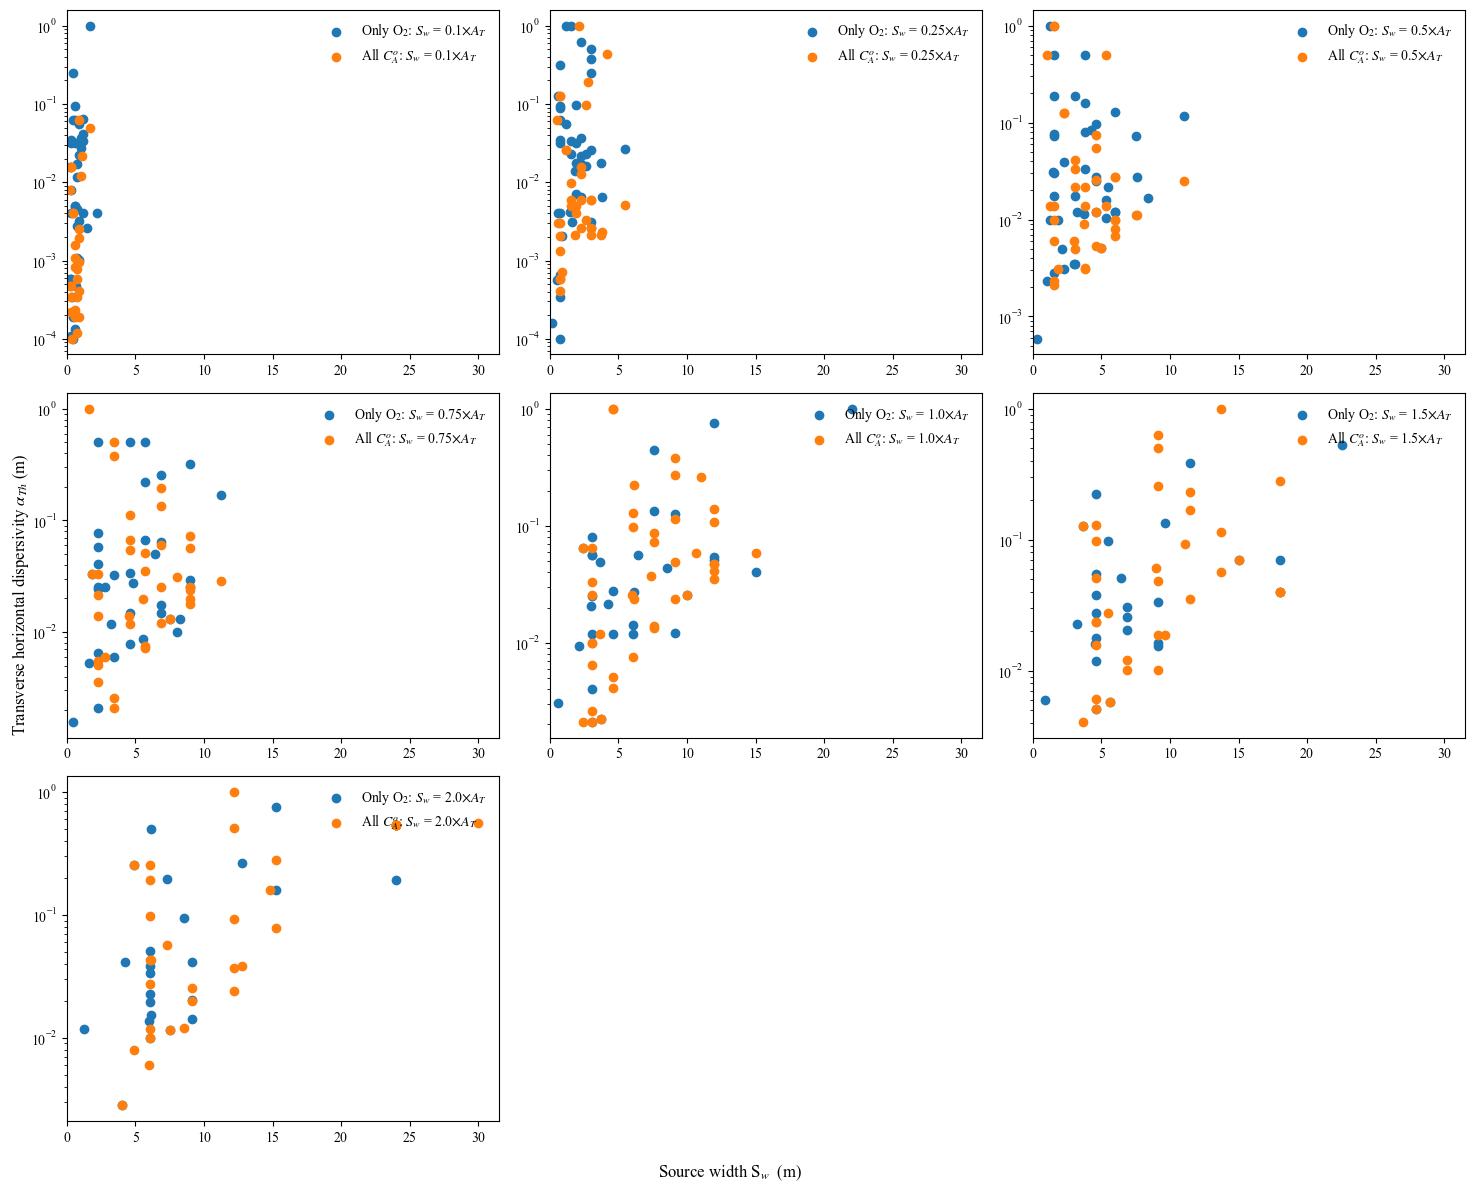

In [12]:
import math

n = len(dfs)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5*ncols, 4*nrows)
)

# fixing the same x-axis limit — use the TRUE max across BOTH O2 and All sheets
global_xmax = max(
    max(df["st"].max() for df in dfs.values()),
    max(df["st"].max() for df in dfs_all.values())
)

axes = axes.flatten()

for ax, phi, (sheet_name, df) in zip(axes, PHIS, dfs.items()):
    all_name = list(dfs_all.keys())[list(dfs.keys()).index(sheet_name)]

    ax.scatter(
        df["st"],
        df["ath"],
        color="tab:blue",
        label=fr"Only O$_2$: $S_w$ = {phi}$\times A_T$"
    )
    # ---- superimpose corresponding "All" sheet ----
    ax.scatter(
        dfs_all[all_name]["st"],
        dfs_all[all_name]["ath"],
        color="tab:orange",
        label=fr"All $C_A^o$: $S_w$ = {phi}$\times A_T$"
    )

    ax.legend(loc="upper right", frameon=False)
    ax.set_xlim(0, global_xmax * 1.05)
    ax.set_yscale("log")

# Hide unused axes
for ax in axes[len(dfs):]:
    ax.set_visible(False)

fig.supxlabel(r"Source width S$_w$  (m)")
fig.supylabel(r"Transverse horizontal dispersivity $\alpha_{Th}$ (m)")
plt.tight_layout()
plt.savefig("S8.pdf", dpi=300)
plt.show()